In [1]:
import sys
import os

import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [2]:
import pandas as pd

In [3]:
dist_out_dir = '/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance'
dist_out_dir_cellchat = '/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_tls-category'

if not os.path.exists (dist_out_dir_cellchat):
    os.makedirs(dist_out_dir_cellchat)

plot_out_dir = os.path.join(dist_out_dir_cellchat, 'plots')
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [4]:
adata = sc.read_h5ad(os.path.join(dist_out_dir,'adata_distance_zones_structure_tls_dist_categories.h5ad'))


In [5]:
adata.obs['label_fine'].unique().tolist()

['Col13a1+ fibroblast',
 'Alv Mf',
 'Cap',
 'Vein',
 'AT2',
 'Mono',
 'Th0',
 'Pericyte 2',
 'Cap-a',
 'Neut',
 'Pericyte 1',
 'Club',
 'Ciliated',
 'Art',
 'AT1',
 'CD4 naive',
 'B cell',
 'Th17',
 'Int Mf',
 'CD8 naive',
 'SMC',
 'gd T cell',
 'Plasmablast',
 'Th2',
 'Lymph',
 'Ccr7- cDC2',
 'NK cell',
 'cDC1',
 'CD4 trans',
 'Ccr7+ cDC2',
 'Th1',
 'CD8 act',
 'Mesothelial',
 'Treg',
 'Myofibroblast',
 'Col14a1+ fibroblast',
 'ILC2']

In [6]:
adata.shape

(593237, 480)

In [7]:
# Categorize by tls-category 
adata = adata[~adata.obs['tls_radial_category'].isna(), :]
# set labels
adata.obs['tls_radial_category'] = adata.obs['tls_radial_category'].values.tolist()
adata.obs['label_fine'] = adata.obs['label_fine'].values.tolist()

In [8]:
adata.shape

(42859, 480)

In [9]:
#wherever cell_type_1 is 'T Cells', add the classification to the cell_type_1 column
# Create a mask for CD4 act
cd4_mask = adata.obs['label_fine'].isin(['Th0', 'Th1', 'Th17', 'Th2', 'Treg', 'CD4 trans'])

# make single activated T cell label per region 
adata.obs.loc[cd4_mask, 'label_fine'] = (
    'CD4 act (' + adata.obs.loc[cd4_mask, 'tls_radial_category'] + ')'
)

# Check the updated cell types
print("Updated T cell categories:")
print(adata.obs.loc[cd4_mask, 'label_fine'].value_counts())

# adata.obs['label_medium']


Updated T cell categories:
label_fine
CD4 act (tls core)        725
CD4 act (tls outer)       604
CD4 act (tls surround)    565
Name: count, dtype: int64


In [10]:
# Check the updated cell types
adata_d3 = adata[adata.obs['sample_label']=='HDM_day3', :]
adata_d30 = adata[adata.obs['sample_label']=='HDM_day30', :]
print("Updated T cell categories, day 3:")
# cd4_mask = adata_d3.obs['label_fine'].isin(['CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'])
# print(adata_d3.obs.loc[cd4_mask, 'label_fine'].value_counts())

print("Updated T cell categories, day 30:")
# cd4_mask = adata_d30.obs['label_fine'].isin(['CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)'])
# print(adata_d30.obs.loc[cd4_mask, 'label_fine'].value_counts())

Updated T cell categories, day 3:
Updated T cell categories, day 30:


In [11]:
# check all cell type counts and fractions
cell_counts = pd.DataFrame(adata_d3.obs.loc[:, 'label_fine'].value_counts())
cell_counts['frac'] = cell_counts['count']/cell_counts['count'].sum()
cell_counts

,count,frac
label_fine,,
B cell,8928,0.228994
AT2,3714,0.095260
Cap,3521,0.090310
Int Mf,2830,0.072586
gd T cell,2153,0.055222
Alv Mf,1931,0.049528
Col14a1+ fibroblast,1823,0.046758
Col13a1+ fibroblast,1318,0.033805
Neut,1140,0.029240


In [12]:
# what about in specific radial categories?
adata_d3_core = adata_d3[adata_d3.obs['tls_radial_category']=='tls core', :]
# core
cell_counts = pd.DataFrame(adata_d3_core.obs.loc[:, 'label_fine'].value_counts())
cell_counts['frac'] = cell_counts['count']/cell_counts['count'].sum()
cell_counts

,count,frac
label_fine,,
B cell,4868,0.506503
gd T cell,602,0.062637
CD4 act (tls core),588,0.061180
Int Mf,525,0.054625
AT2,504,0.052440
Cap,309,0.032151
Col14a1+ fibroblast,279,0.029029
Plasmablast,230,0.023931
cDC1,158,0.016439


In [13]:
# what about in specific radial categories?
adata_d3_outer = adata_d3[adata_d3.obs['tls_radial_category']=='tls outer', :]
# outer
cell_counts = pd.DataFrame(adata_d3_outer.obs.loc[:, 'label_fine'].value_counts())
cell_counts['frac'] = cell_counts['count']/cell_counts['count'].sum()
cell_counts

,count,frac
label_fine,,
B cell,2760,0.300686
AT2,815,0.088790
Int Mf,687,0.074845
gd T cell,655,0.071359
Cap,592,0.064495
CD4 act (tls outer),494,0.053818
Col14a1+ fibroblast,429,0.046737
Alv Mf,270,0.029415
Plasmablast,265,0.028870


In [17]:
# what about in specific radial categories?
adata_d3_surround = adata_d3[adata_d3.obs['tls_radial_category']=='tls surround', :]
# outer
cell_counts = pd.DataFrame(adata_d3_surround.obs.loc[:, 'label_fine'].value_counts())
cell_counts['frac'] = cell_counts['count']/cell_counts['count'].sum()
cell_counts

,count,frac
label_fine,,
Cap,2620,0.129716
AT2,2395,0.118576
Int Mf,1618,0.080107
Alv Mf,1523,0.075404
B cell,1300,0.064363
Col14a1+ fibroblast,1115,0.055203
Col13a1+ fibroblast,1044,0.051688
gd T cell,896,0.044361
Neut,824,0.040796


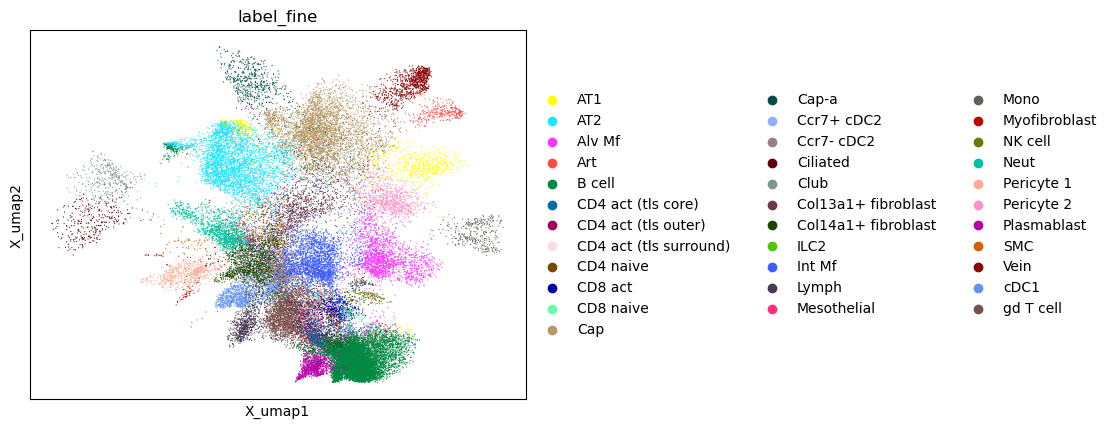

In [14]:
sc.pl.embedding(adata, basis='X_umap', color = 'label_fine')

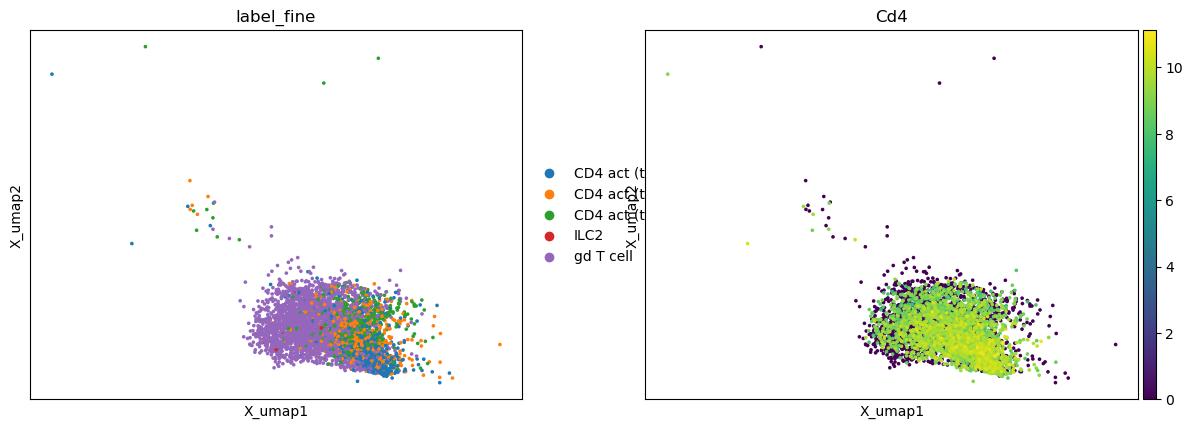

In [22]:
sc.pl.embedding(adata[adata.obs['label_fine'].isin(['ILC2', 'gd T cell', 'CD4 act (tls core)', 'CD4 act (tls outer)', 'CD4 act (tls surround)']), :],
                basis='X_umap', color = ['label_fine', 'Cd4'])

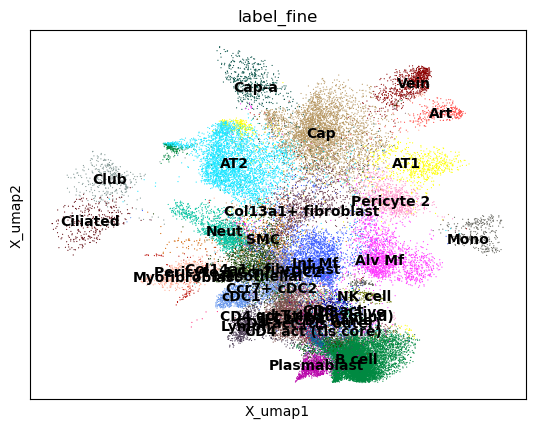

In [15]:
sc.pl.embedding(adata, basis='X_umap', color = 'label_fine', legend_loc = 'on data')

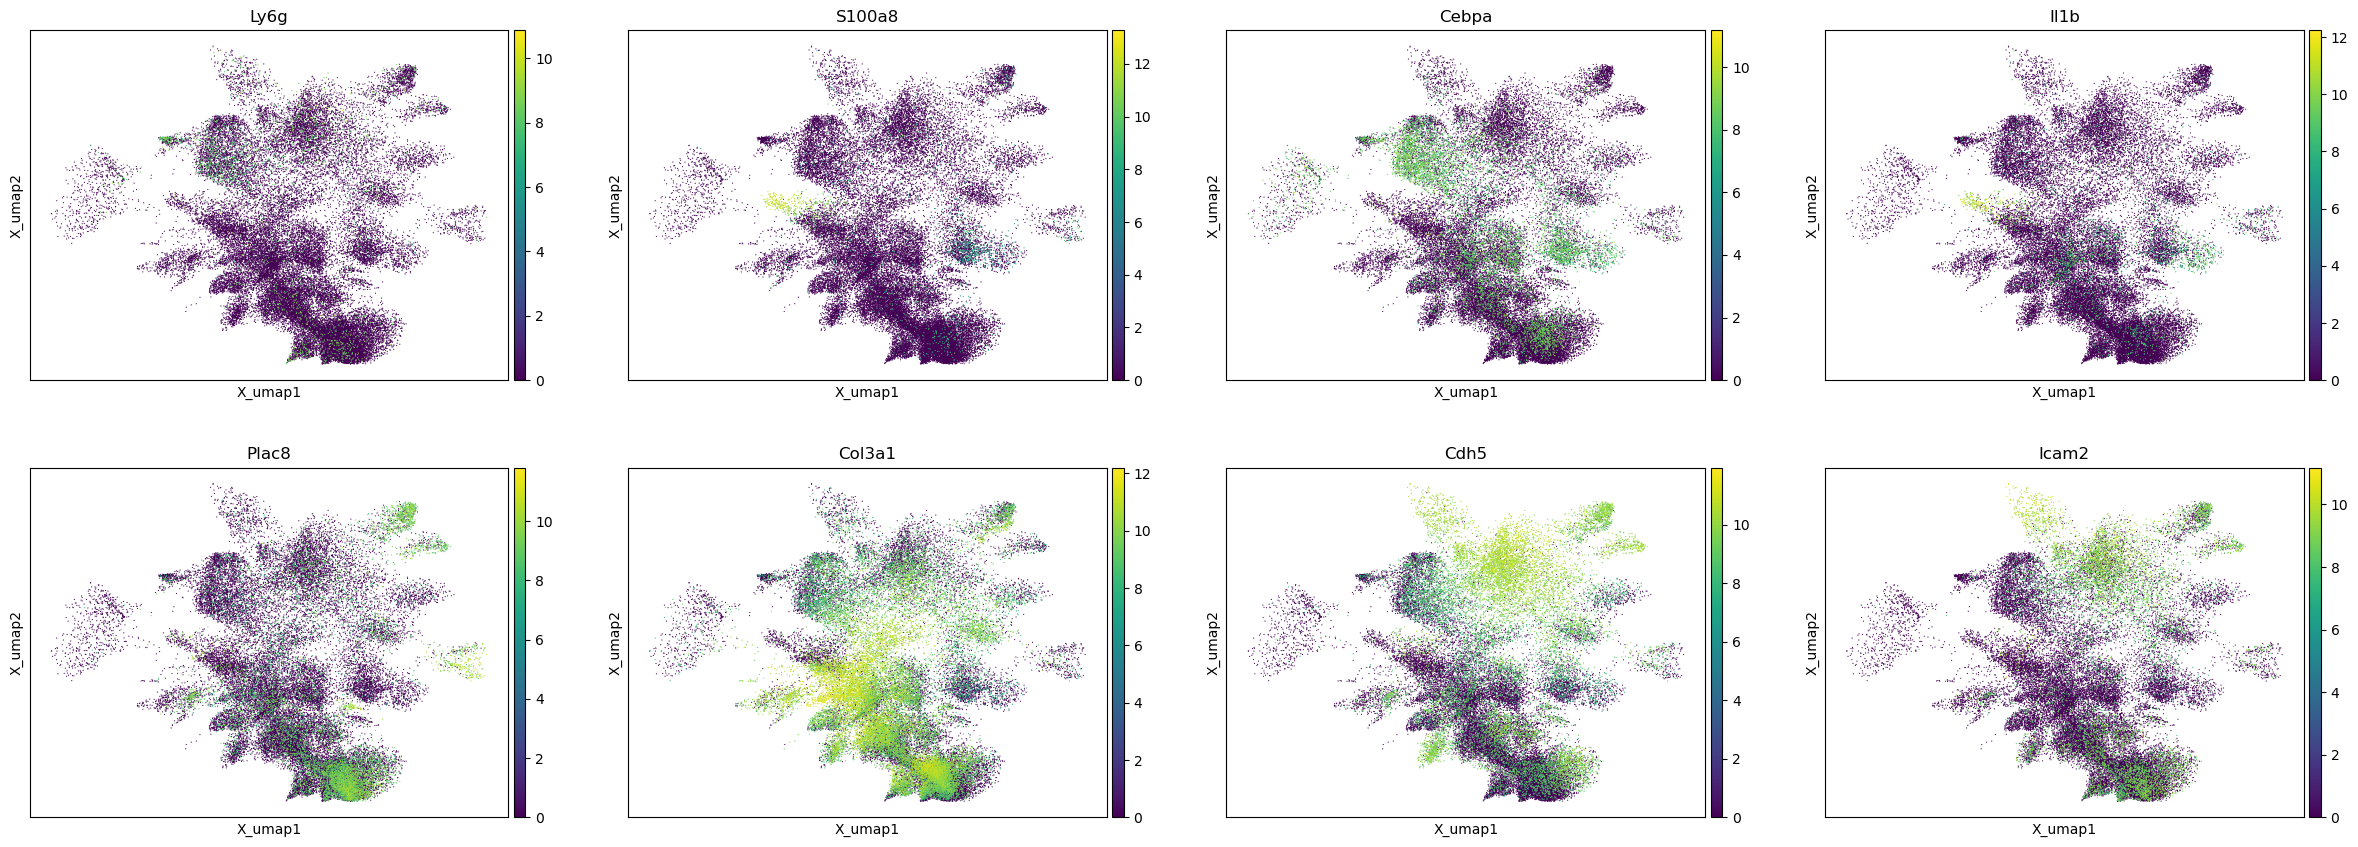

In [16]:
sc.pl.embedding(adata, basis='X_umap', color = ['Ly6g', 'S100a8','Cebpa', 'Il1b', 'Plac8',
                                                'Col3a1', 'Cdh5', 'Icam2'])

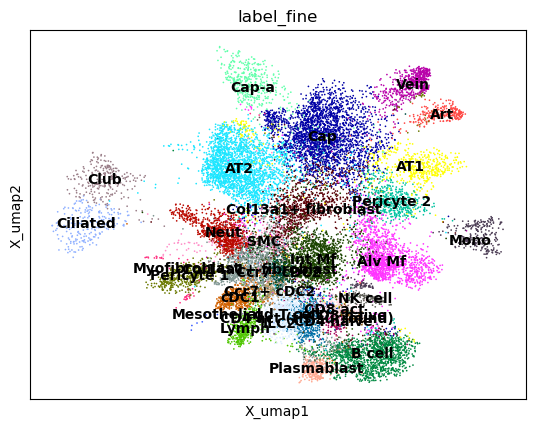

In [18]:
sc.pl.embedding(adata_d3_surround, basis='X_umap', color = 'label_fine', legend_loc = 'on data')

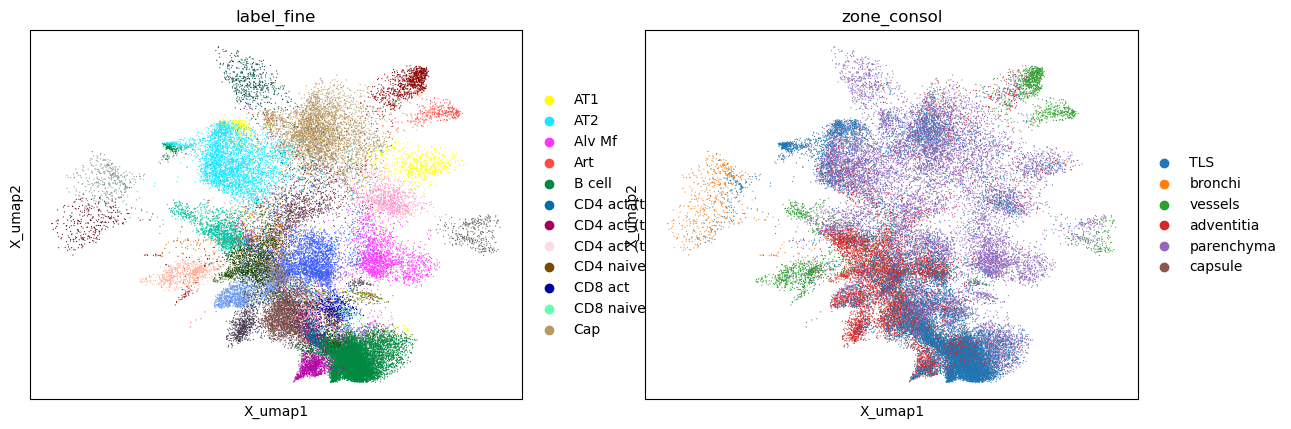

In [27]:
sc.pl.embedding(adata, basis='X_umap', color = ['label_fine', 'zone_consol'])

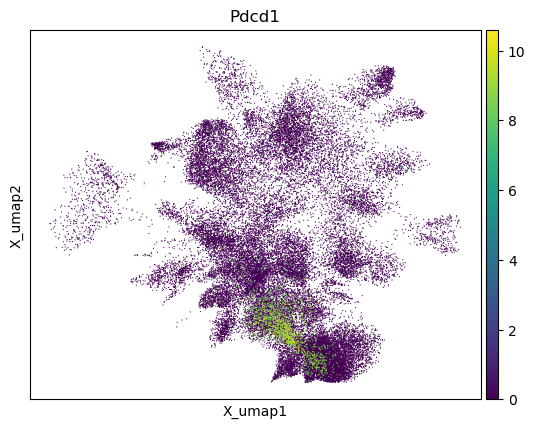

In [23]:
sc.pl.embedding(adata, basis='X_umap', color = 'Pdcd1')

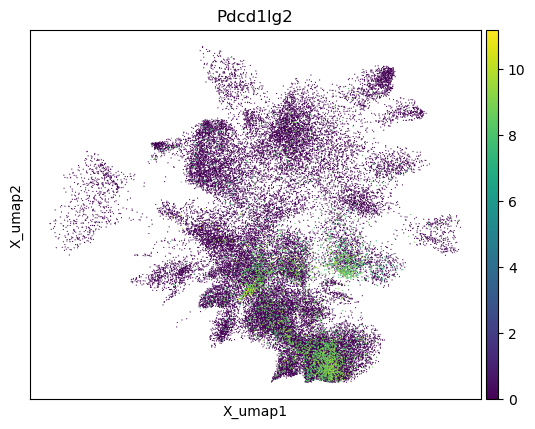

In [25]:
sc.pl.embedding(adata, basis='X_umap', color = 'Pdcd1lg2')

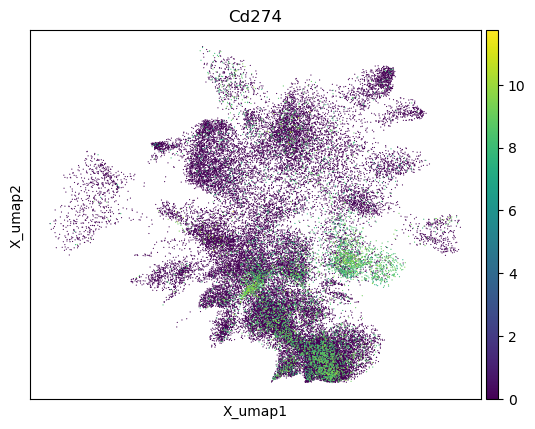

In [26]:
sc.pl.embedding(adata, basis='X_umap', color = 'Cd274')

In [ ]:
sc.pl.violin 

In [47]:
# Do I need to normalize again? 
# I don't think so unless there is a requirement by cellchat to normalize to a particular target sum
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

In [44]:
adata.write_h5ad(os.path.join(dist_out_dir_cellchat,'adata_cellchat_prepped.h5ad'))

In [18]:
dist_out_dir_cellchat

'/home/workspace/spatial_mouse_lung_outputs/downstream_analysis/distance/cellchat_tls-category'